### Unsupervised MLP_AE Model for Home A (Simulated and Real Test Set)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
# X = data_df.drop(columns=["Label"])  # Drop the label column
# y = data_df["Label"]

X_train = data_df.drop(columns=["Label"])  # Drop the label column
y_test = data_df["Label"]

# Split the data into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X_train shape:", X_train.shape)
print("y_test shape:", y_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
#print("y_train shape:", y_train.shape)


X_train shape: (35040, 1380)
y_test shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [4]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0166 - val_loss: 0.0099
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0078 - val_loss: 0.0066
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 7/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0038 - val_loss: 0.0040
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0036 - val_lo

986/986 [==============================] - 3s 3ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 82/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 83/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 84/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 85/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 86/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 87/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 88/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 89/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 90/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0028 - val_loss: 

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense (Dense)               (None, 32)                44192     
                                                                 
 dense_1 (Dense)             (None, 128)               4224      
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 128)               8320      
                                                                 
 dense_4 (Dense)             (None, 1380)              178020    
                                                                 
Total params: 243,012
Trainable params: 243,012
Non-trainable

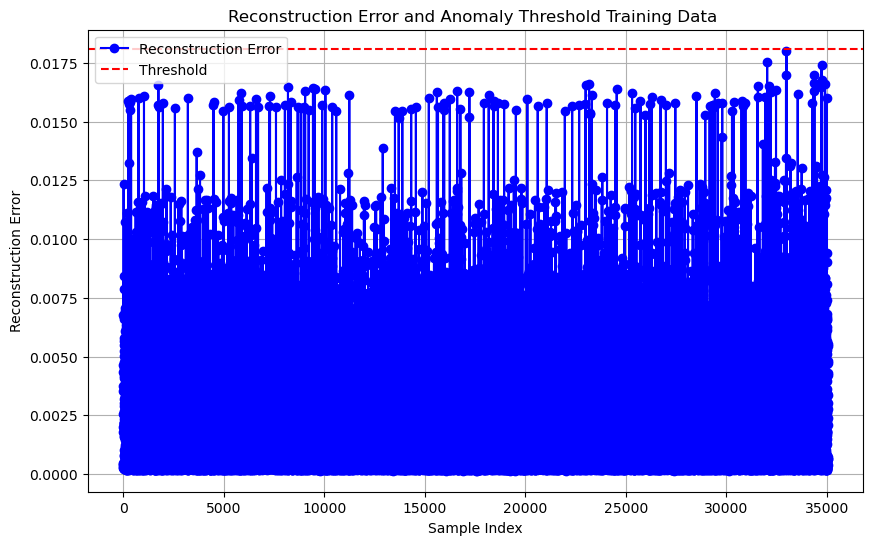

In [24]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (10 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
# data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
# train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
# X_train = train_data.drop(columns=['Label']).values
# y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Print reconstruction errors
print("Test Reconstruction Errors:")
print(test_reconstruction_error)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


10/10 [==============================] - 0s 2ms/step
Test Reconstruction Errors:
[0.00630802 0.00809885 0.00072527 0.00850368 0.00596835 0.00665079
 0.00089643 0.0054683  0.00874596 0.02340199 0.00490243 0.00259108
 0.01196277 0.01435891 0.00424459 0.00953785 0.00584119 0.00432619
 0.01474893 0.01225939 0.00636689 0.01604762 0.02396493 0.00170625
 0.00684151 0.00379105 0.00021717 0.01075222 0.02595498 0.00249094
 0.02971797 0.0117013  0.01618782 0.00378285 0.01356805 0.0127803
 0.00574446 0.01834503 0.00226494 0.00360815 0.0238234  0.00442198
 0.09672049 0.00727887 0.00260511 0.00335196 0.01348345 0.01056403
 0.00277284 0.00262814 0.00612249 0.00096677 0.0017083  0.0174974
 0.00172451 0.00248394 0.01078557 0.02421425 0.00408742 0.0015277
 0.00325258 0.00313052 0.02072872 0.01781275 0.00463914 0.00348263
 0.00924946 0.00534826 0.00517348 0.01124941 0.00083418 0.00985099
 0.02849634 0.06425354 0.01912639 0.00814604 0.00390998 0.0194287
 0.00592266 0.0024434  0.01060229 0.00809049 0.00208

In [54]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5827586206896552
Precision: 0.8108108108108109
Recall: 0.20833333333333334
TNR: 0.952054794520548
FPR: 0.04794520547945205
FNR: 0.7916666666666666
F1 Score: 0.33149171270718236
ROC AUC: 0.7471461187214612


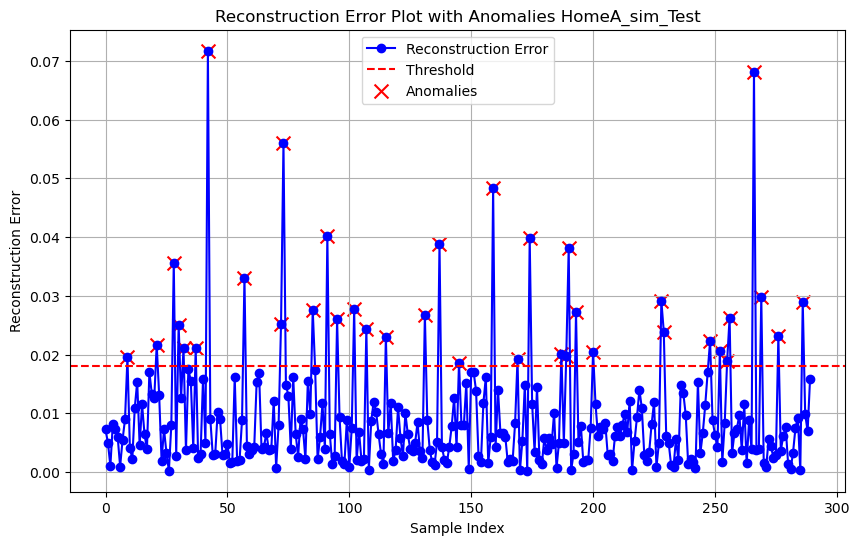

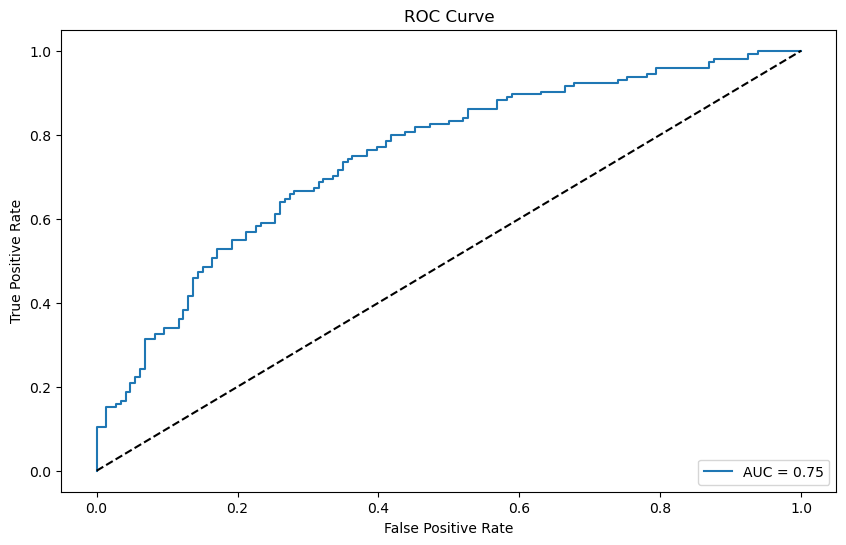

In [55]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
# data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
# train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
# X_train = train_data.drop(columns=['Label']).values
# y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
real_test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Print reconstruction errors
print("Real Test Reconstruction Errors:")
print(real_test_reconstruction_error)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = real_test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 2ms/step
Real Test Reconstruction Errors:
[0.01031653 0.00356167 0.00197372 ... 0.0031824  0.0112659  0.01807426]
Threshold saved at: 0.01806561017243623
Anomalous Data Indices:
[   18    92    98 ... 17499 17510 17519]


In [18]:
real_test_reconstruction_error

array([0.01031653, 0.00356167, 0.00197372, ..., 0.0031824 , 0.0112659 ,
       0.01807426])

In [19]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [20]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5073630136986301
Precision: 0.564051638530288
Recall: 0.06484018264840183
TNR: 0.9498858447488584
FPR: 0.05011415525114155
FNR: 0.9351598173515981
F1 Score: 0.11631002354868435
ROC AUC: 0.5798235806175851


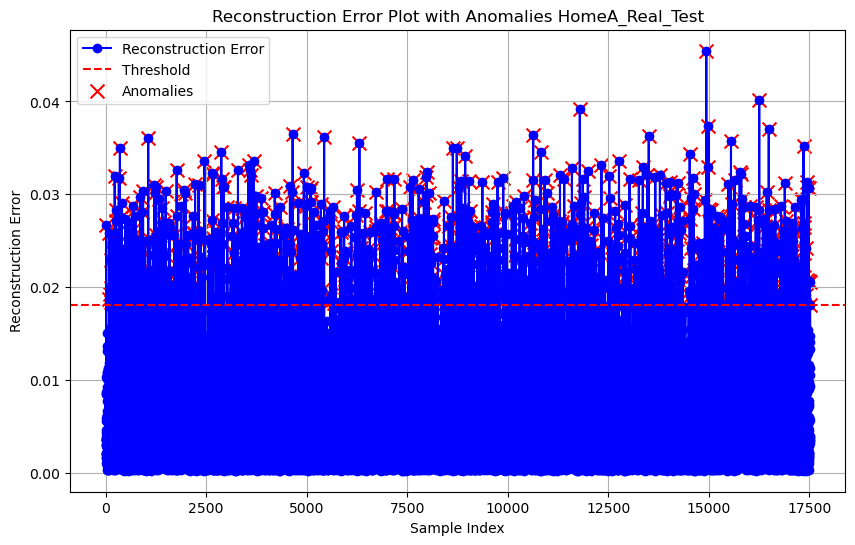

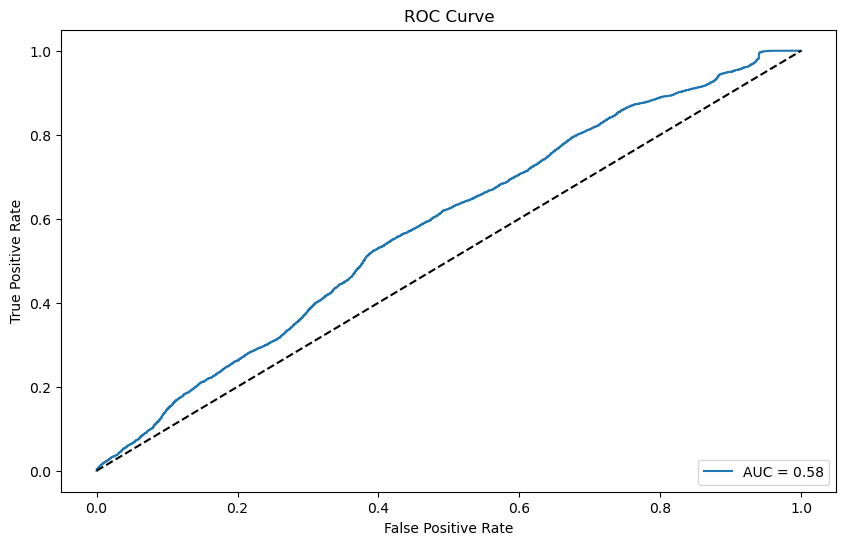

In [23]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, real_test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, real_test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(real_test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, real_test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
